# Notebook 04 — Clustering & Hotspot Detection (Stage 3)
Clusters districts by waste level, detects hotspots, and assigns land-use categories.

Uses **PREDICTED** next-month waste (from Notebook 03) for waste-level clustering, and **HISTORICAL** actual data for volatility/stability features and a comparison baseline.

**Input:** `next_month_forecast.parquet`, `features.parquet`, `districts.geojson`
**Output:** `district_clusters.parquet`, `category_stats_predicted.csv`, `category_stats_historical.csv`

In [2]:
# Setup: imports, paths, and load PREDICTED forecast + HISTORICAL data + district shapes.
import os
os.environ["OMP_NUM_THREADS"] = "1"  # suppresses a harmless KMeans warning on Windows

import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

%matplotlib inline

PROJECT_ROOT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
PROCESSED = PROJECT_ROOT / "data" / "processed"

forecast = pd.read_parquet(PROCESSED / "next_month_forecast.parquet")   # PREDICTED
history = pd.read_parquet(PROCESSED / "features.parquet")               # HISTORICAL
districts_gdf = gpd.read_file(PROCESSED / "districts.geojson")

print("forecast (PREDICTED):", forecast.shape)
print("history (HISTORICAL):", history.shape)

C:\Users\pande\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


forecast (PREDICTED): (59, 15)
history (HISTORICAL): (24411, 27)


In [3]:
# Build per-district summary: PREDICTED next-month waste level + HISTORICAL volatility
# (used together to both cluster districts and later infer land-use category).
hist_stats = history.groupby("BoroCd")["total_tons"].agg(hist_avg="mean", hist_std="std").reset_index()
hist_stats["hist_cv"] = hist_stats["hist_std"] / hist_stats["hist_avg"]

district_summary = forecast[["BoroCd", "predicted_tons"]].merge(hist_stats, on="BoroCd", how="left")

print("district_summary shape:", district_summary.shape)  # expect (59, 5)
district_summary.sort_values("predicted_tons", ascending=False).head()

district_summary shape: (59, 5)


,BoroCd,predicted_tons,hist_avg,hist_std,hist_cv
48,407,11154.379155,8745.632614,1499.684542,0.171478
34,311,9464.657567,7852.756174,1502.086451,0.191281
53,412,9389.116680,8232.745084,1087.282411,0.132068
13,202,8607.867505,5837.756934,3155.431816,0.540521
58,503,7393.248495,7246.737530,1136.638780,0.156848


In [4]:
# Scale clustering features (PREDICTED level + HISTORICAL volatility) — required since
# K-Means/DBSCAN are distance-based and the two features are on very different scales.
cluster_features = ["predicted_tons", "hist_cv"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(district_summary[cluster_features])
pd.DataFrame(X_scaled, columns=cluster_features).describe()

,predicted_tons,hist_cv
count,5.900000e+01,5.900000e+01
mean,2.559158e-16,-7.291719e-17
std,1.008584e+00,1.008584e+00
min,-1.723745e+00,-9.006705e-01
25%,-7.245164e-01,-5.751858e-01
50%,-4.051753e-02,-3.098937e-01
75%,5.595988e-01,2.441719e-01
max,3.241414e+00,5.371770e+00


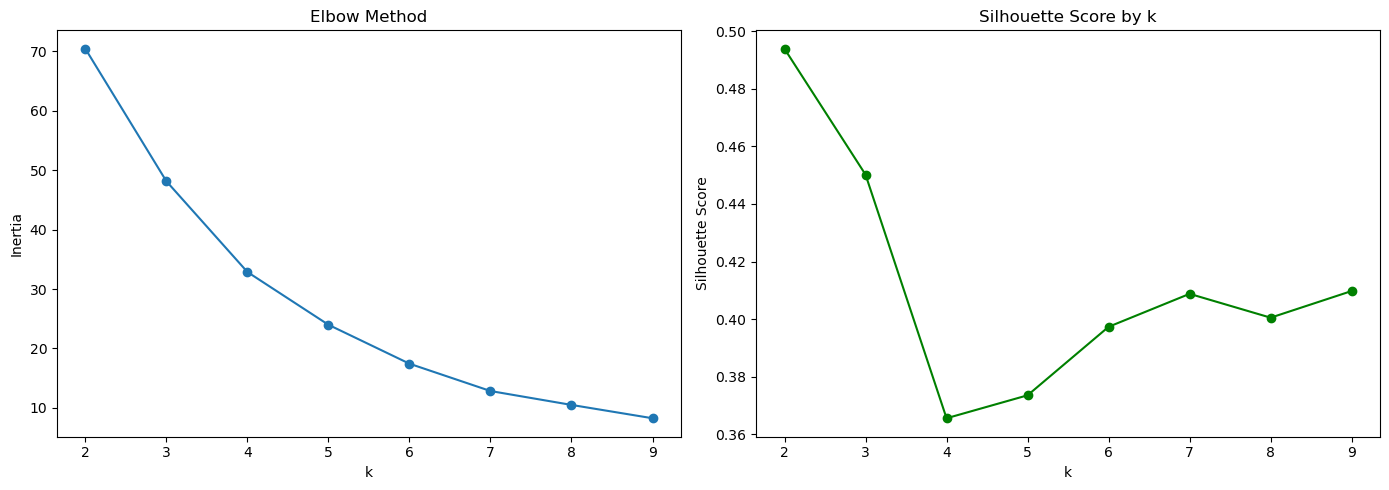

k=3 selected — best silhouette score among options with a reasonable, interpretable cluster count


In [5]:
# Choose k via elbow method + silhouette score. k=3 was selected: silhouette score for k=3
# (0.450) is clearly better than k=4 (0.366), so the statistically-justified choice was used
# over the less-rigorous "visual elbow" reading.
inertias, silhouette_scores = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set(xlabel="k", ylabel="Inertia", title="Elbow Method")
axes[1].plot(K_range, silhouette_scores, marker="o", color="green")
axes[1].set(xlabel="k", ylabel="Silhouette Score", title="Silhouette Score by k")
plt.tight_layout()
plt.savefig(PROCESSED / "kmeans_k_selection.png", dpi=150)
plt.show()

print("k=3 selected — best silhouette score among options with a reasonable, interpretable cluster count")

In [6]:
# K-Means clustering (k=3) on PREDICTED waste level + historical volatility.
# Clusters are relabeled so 0=Low, 1=Medium, 2=High waste (K-Means cluster IDs are arbitrary by default).
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_summary["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

cluster_order = district_summary.groupby("kmeans_cluster")["predicted_tons"].mean().sort_values().index
remap = {old: new for new, old in enumerate(cluster_order)}
district_summary["kmeans_cluster"] = district_summary["kmeans_cluster"].map(remap)

cluster_labels = {0: "Low Waste", 1: "Medium Waste", 2: "High Waste"}
district_summary["cluster_label"] = district_summary["kmeans_cluster"].map(cluster_labels)

district_summary.groupby("cluster_label")[["predicted_tons", "hist_avg", "hist_cv"]].agg(["mean", "count"])

predicted_tons           hist_avg         hist_cv      
                        mean count         mean count      mean count
cluster_label                                                        
High Waste       8607.867505     1  5837.756934     1  0.540521     1
Low Waste        4480.863706    44  4389.068533    44  0.119974    44
Medium Waste     7581.731100    14  6974.657139    14  0.175672    14

In [7]:
# Comparison baseline: separate K-Means run using HISTORICAL averages only (not PREDICTED),
# to confirm PREDICTED-based clusters are consistent with long-term historical reality.
hist_features = ["hist_avg", "hist_cv"]
X_hist_scaled = StandardScaler().fit_transform(district_summary[hist_features])

kmeans_hist = KMeans(n_clusters=3, random_state=42, n_init=10)
district_summary["kmeans_cluster_HISTORICAL"] = kmeans_hist.fit_predict(X_hist_scaled)

order_hist = district_summary.groupby("kmeans_cluster_HISTORICAL")["hist_avg"].mean().sort_values().index
remap_hist = {old: new for new, old in enumerate(order_hist)}
district_summary["kmeans_cluster_HISTORICAL"] = district_summary["kmeans_cluster_HISTORICAL"].map(remap_hist)
district_summary["cluster_label_HISTORICAL"] = district_summary["kmeans_cluster_HISTORICAL"].map(cluster_labels)

district_summary.groupby("cluster_label_HISTORICAL")[["hist_avg", "hist_cv"]].agg(["mean", "count"])

hist_avg         hist_cv      
                                 mean count      mean count
cluster_label_HISTORICAL                                   
High Waste                6855.138766    19  0.134969    19
Low Waste                 4117.976190    35  0.115615    35
Medium Waste              4445.033833     5  0.333574     5

In [8]:
# DBSCAN hotspot/anomaly detection — flags districts (-1 label) that don't fit any dense
# cluster, i.e. genuine outlier "hotspots" rather than just the top of the K-Means High tier.
dbscan = DBSCAN(eps=0.8, min_samples=3)
district_summary["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_outliers = (district_summary["dbscan_cluster"] == -1).sum()
print(f"DBSCAN found {n_outliers} outlier (hotspot) districts")
district_summary[district_summary["dbscan_cluster"] == -1][["BoroCd", "predicted_tons", "hist_cv", "cluster_label"]]

DBSCAN found 5 outlier (hotspot) districts


,BoroCd,predicted_tons,hist_cv,cluster_label
0,101,2166.203745,0.311053,Low Waste
13,202,8607.867505,0.540521,High Waste
34,311,9464.657567,0.191281,Medium Waste
48,407,11154.379155,0.171478,Medium Waste
53,412,9389.116680,0.132068,Medium Waste


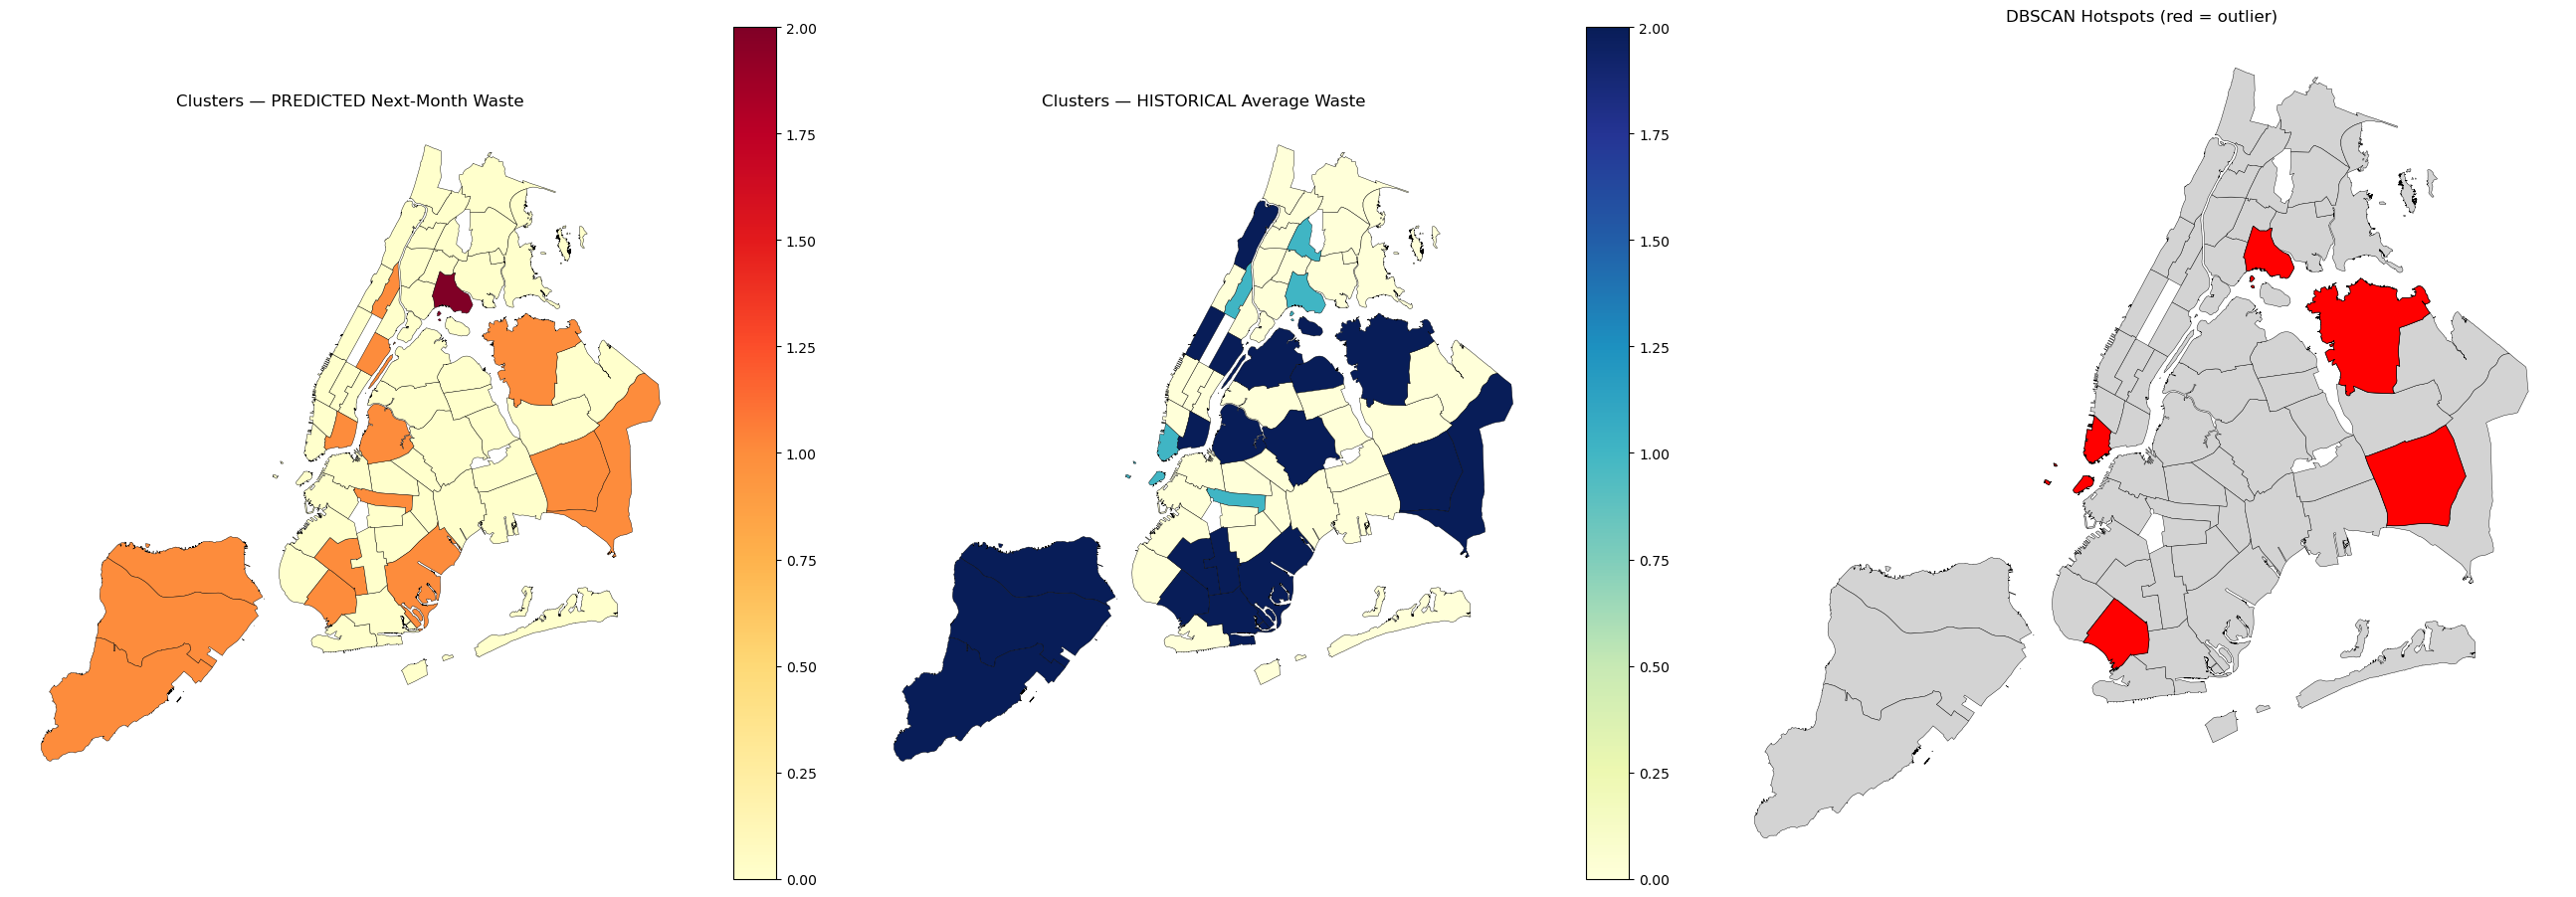

In [9]:
# Map: PREDICTED-based clusters vs HISTORICAL-based clusters, side by side, plus DBSCAN
# hotspot districts highlighted in red.
merged = districts_gdf.merge(district_summary, on="BoroCd")

fig, axes = plt.subplots(1, 3, figsize=(26, 9))

merged.plot(column="kmeans_cluster", cmap="YlOrRd", legend=True, ax=axes[0], edgecolor="black", linewidth=0.3)
axes[0].set_title("Clusters — PREDICTED Next-Month Waste")
axes[0].axis("off")

merged.plot(column="kmeans_cluster_HISTORICAL", cmap="YlGnBu", legend=True, ax=axes[1], edgecolor="black", linewidth=0.3)
axes[1].set_title("Clusters — HISTORICAL Average Waste")
axes[1].axis("off")

merged.plot(ax=axes[2], color="lightgrey", edgecolor="black", linewidth=0.3)
merged[merged["dbscan_cluster"] == -1].plot(ax=axes[2], color="red", edgecolor="black", linewidth=0.5)
axes[2].set_title("DBSCAN Hotspots (red = outlier)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(PROCESSED / "cluster_and_hotspot_maps.png", dpi=150)
plt.show()

In [10]:
# Land-use categorization: rule-based heuristic combining PREDICTED waste tier with
# HISTORICAL volatility (stable vs. spiky pattern). This is a heuristic, not ground-truth
# zoning data — stated explicitly as a limitation in the report.
def assign_landuse(row):
    level, cv = row["cluster_label"], row["hist_cv"]
    if level == "Low Waste":
        return "Residential" if cv < 0.20 else "Institutional"
    elif level == "Medium Waste":
        return "Mixed-Use" if cv < 0.20 else "Commercial"
    else:
        return "Industrial" if cv < 0.20 else "Market Area"

district_summary["land_use_category"] = district_summary.apply(assign_landuse, axis=1)
district_summary["land_use_category"].value_counts()

land_use_category
Residential      42
Mixed-Use        11
Commercial        3
Institutional     2
Market Area       1
Name: count, dtype: int64

In [11]:
# Category-level statistics (PREDICTED and HISTORICAL side by side) — total waste, average
# waste, block count, and % of city total per land-use category, as required by the project brief.
category_stats_pred = district_summary.groupby("land_use_category").agg(
    num_blocks=("BoroCd", "count"), total_waste=("predicted_tons", "sum"), avg_waste=("predicted_tons", "mean"),
).reset_index()
category_stats_pred["pct_of_city_total"] = category_stats_pred["total_waste"] / category_stats_pred["total_waste"].sum() * 100
category_stats_pred = category_stats_pred.sort_values("total_waste", ascending=False)

category_stats_hist = district_summary.groupby("land_use_category").agg(
    num_blocks=("BoroCd", "count"), total_waste=("hist_avg", "sum"), avg_waste=("hist_avg", "mean"),
).reset_index()
category_stats_hist["pct_of_city_total"] = category_stats_hist["total_waste"] / category_stats_hist["total_waste"].sum() * 100
category_stats_hist = category_stats_hist.sort_values("total_waste", ascending=False)

print("PREDICTED (next month):")
display(category_stats_pred)
print("\nHISTORICAL (all-time average):")
display(category_stats_hist)

PREDICTED (next month):


,land_use_category,num_blocks,total_waste,avg_waste,pct_of_city_total
4,Residential,42,191133.430323,4550.795960,61.278370
3,Mixed-Use,11,85717.772911,7792.524810,27.481563
0,Commercial,3,20426.462483,6808.820828,6.548830
2,Market Area,1,8607.867505,8607.867505,2.759727
1,Institutional,2,6024.572721,3012.286361,1.931509



HISTORICAL (all-time average):


,land_use_category,num_blocks,total_waste,avg_waste,pct_of_city_total
4,Residential,42,187543.837091,4465.329455,63.230813
3,Mixed-Use,11,80681.997287,7334.727026,27.202111
0,Commercial,3,16963.202660,5654.400887,5.719181
2,Market Area,1,5837.756934,5837.756934,1.968212
1,Institutional,2,5575.178383,2787.589191,1.879684


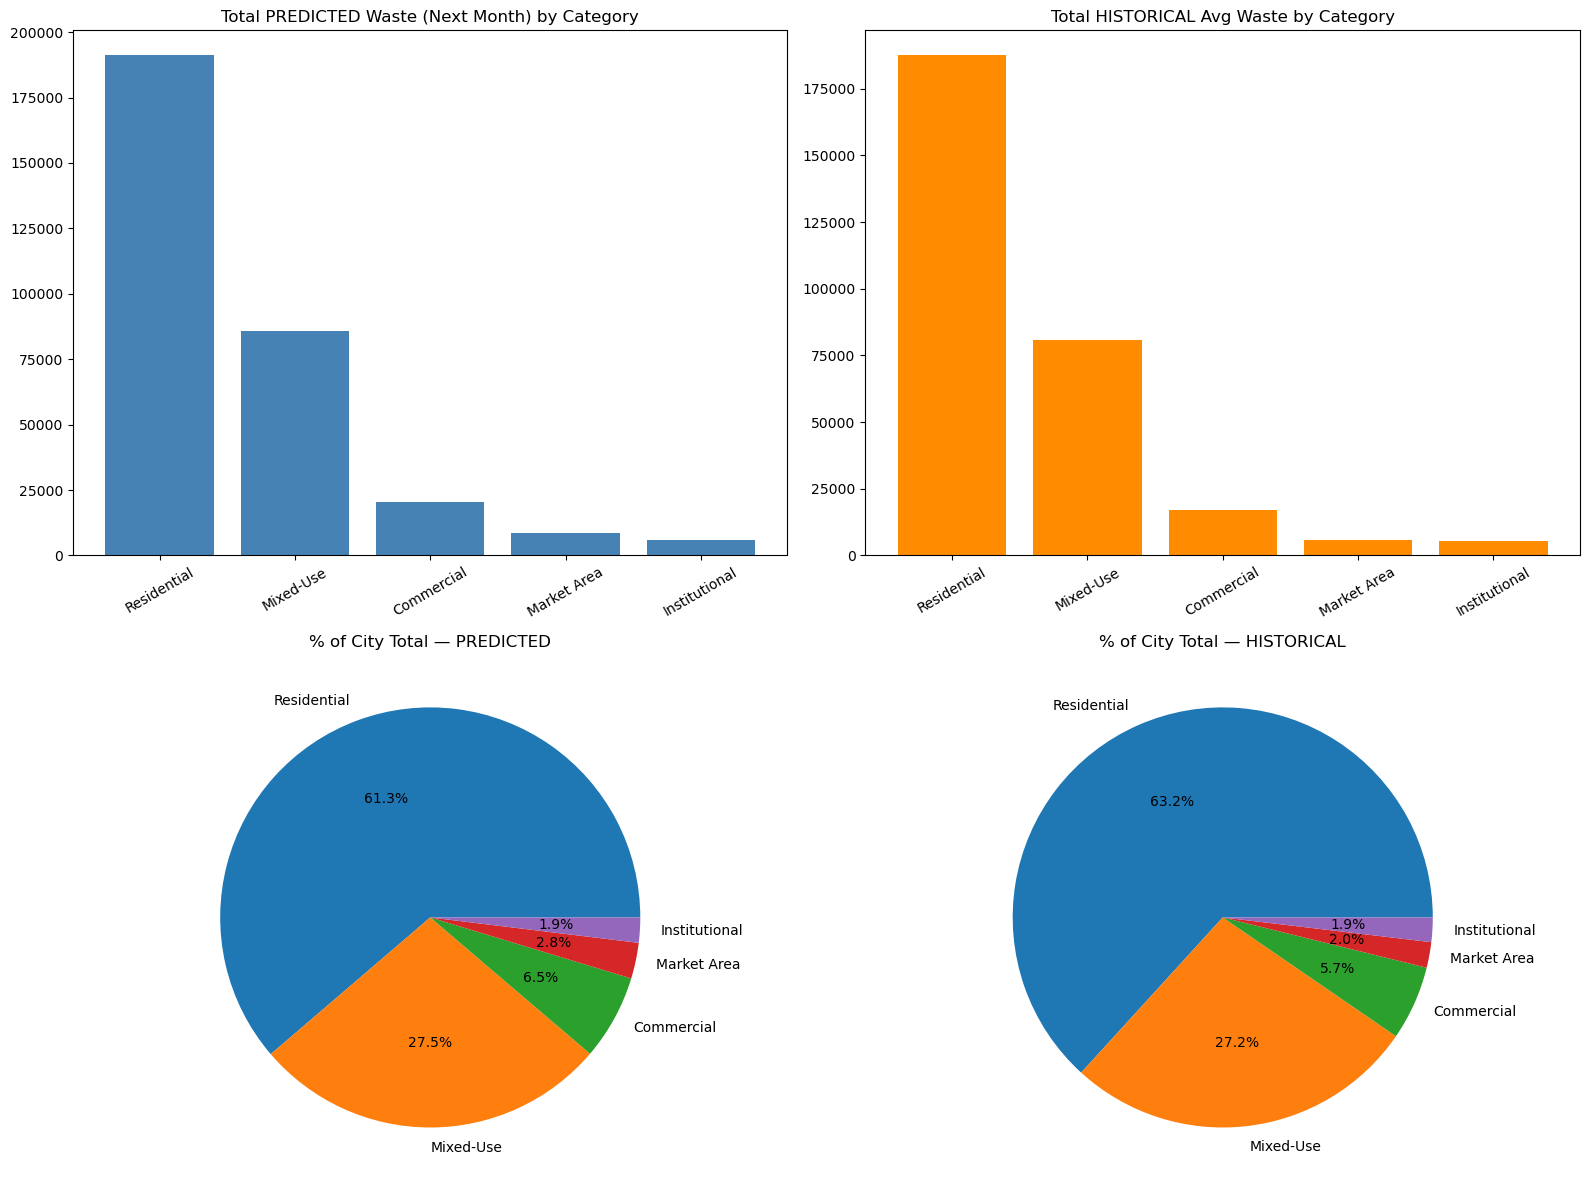

In [12]:
# Visualize category distribution: PREDICTED vs HISTORICAL, bar + pie charts side by side.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(category_stats_pred["land_use_category"], category_stats_pred["total_waste"], color="steelblue")
axes[0, 0].set_title("Total PREDICTED Waste (Next Month) by Category")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].bar(category_stats_hist["land_use_category"], category_stats_hist["total_waste"], color="darkorange")
axes[0, 1].set_title("Total HISTORICAL Avg Waste by Category")
axes[0, 1].tick_params(axis="x", rotation=30)

axes[1, 0].pie(category_stats_pred["pct_of_city_total"], labels=category_stats_pred["land_use_category"], autopct="%1.1f%%")
axes[1, 0].set_title("% of City Total — PREDICTED")

axes[1, 1].pie(category_stats_hist["pct_of_city_total"], labels=category_stats_hist["land_use_category"], autopct="%1.1f%%")
axes[1, 1].set_title("% of City Total — HISTORICAL")

plt.tight_layout()
plt.savefig(PROCESSED / "landuse_category_stats.png", dpi=150)
plt.show()

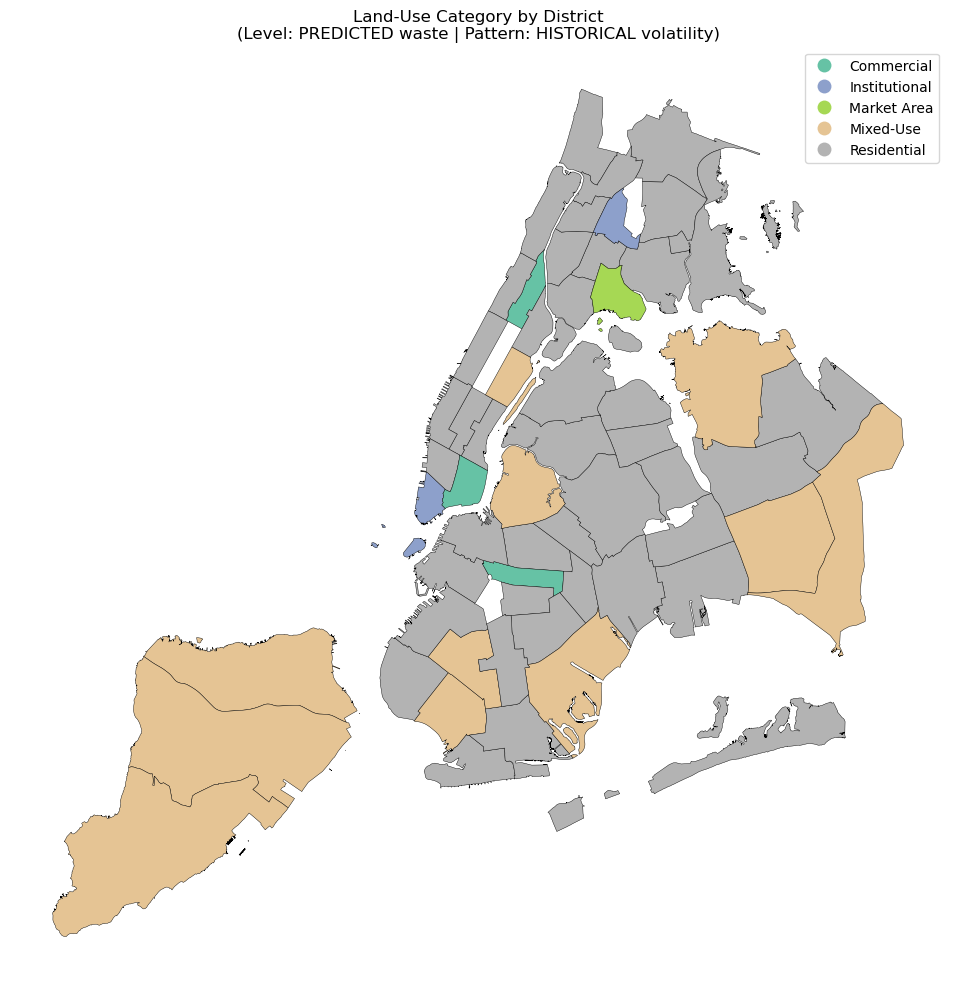

In [14]:
# Map: land-use category per district (hybrid PREDICTED level + HISTORICAL volatility pattern).
# Re-merge here so we pick up land_use_category, which was added to district_summary after
# `merged` was first built in the DBSCAN cell above.
merged = districts_gdf.merge(district_summary, on="BoroCd")

fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(column="land_use_category", categorical=True, legend=True, ax=ax, edgecolor="black", linewidth=0.3, cmap="Set2")
ax.set_title("Land-Use Category by District\n(Level: PREDICTED waste | Pattern: HISTORICAL volatility)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "landuse_category_map.png", dpi=150)
plt.show()

In [15]:
# Save final Stage 3 outputs. Re-running this notebook overwrites these same filenames.
district_summary.to_parquet(PROCESSED / "district_clusters.parquet", index=False)
category_stats_pred.to_csv(PROCESSED / "category_stats_predicted.csv", index=False)
category_stats_hist.to_csv(PROCESSED / "category_stats_historical.csv", index=False)

print("Saved:")
print(" -", PROCESSED / "district_clusters.parquet")
print(" -", PROCESSED / "category_stats_predicted.csv")
print(" -", PROCESSED / "category_stats_historical.csv")
print("\nNotebook 04 complete.", district_summary.shape[0], "districts clustered and categorized.")

Saved:
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\district_clusters.parquet
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\category_stats_predicted.csv
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\category_stats_historical.csv

Notebook 04 complete. 59 districts clustered and categorized.
